In [7]:
pip install yfinance



     ---------------------------------------- 0.0/948.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/948.2 kB ? eta -:--:--
     --------------------- ---------------- 524.3/948.2 kB 1.9 MB/s eta 0:00:01
     -------------------------------------- 948.2/948.2 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for peewee: filename=peewee-3.17.8-py3-none-any.whl size=139064 sha256=5f9596b1bf64b5f80ecacd02bdad178c4da307e4d2bd5836934015ac436887fc
  Stored in directory: c:\users\aniket\appdata\local\pip\cache\wheels\8f\65\34\456800445efeafb05164fe95285c70e81ba1d96bae30f43917
Successfully built peewee


In [3]:
pip install pandas_datareader

   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   -------- ------------------------------- 0.8/3.8 MB 4.8 MB/s eta 0:00:01
   ---------------- ----------------------- 1.6/3.8 MB 3.8 MB/s eta 0:00:01
   ------------------- -------------------- 1.8/3.8 MB 3.5 MB/s eta 0:00:01
   ------------------------ --------------- 2.4/3.8 MB 3.0 MB/s eta 0:00:01
   -------------------------------- ------- 3.1/3.8 MB 3.0 MB/s eta 0:00:01
   -------------------------------------- - 3.7/3.8 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 3.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data
import yfinance as yf


In [8]:
import yfinance as yf

start = '2010-01-01'
end = '2019-12-31'

df = yf.download('AAPL', start=start, end=end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.447410,6.462172,6.398304,6.429937,493729600
2010-01-05,6.458560,6.495014,6.424517,6.465188,601904800
2010-01-06,6.355826,6.484166,6.349198,6.458558,552160000
2010-01-07,6.344077,6.386858,6.297983,6.379326,477131200
2010-01-08,6.386256,6.386859,6.298287,6.335643,447610800


In [9]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-12-23,68.833260,68.893852,67.953453,67.992233,98572000
2019-12-24,68.898697,69.048973,68.571502,69.000496,48478800
2019-12-26,70.265678,70.282646,69.002929,69.032013,93121200
2019-12-27,70.239014,71.249703,69.831833,70.558945,146266000
2019-12-30,70.655884,70.939461,69.128952,70.156601,144114400


In [10]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.447410,6.462172,6.398304,6.429937,493729600
1,2010-01-05,6.458560,6.495014,6.424517,6.465188,601904800
2,2010-01-06,6.355826,6.484166,6.349198,6.458558,552160000
3,2010-01-07,6.344077,6.386858,6.297983,6.379326,477131200
4,2010-01-08,6.386256,6.386859,6.298287,6.335643,447610800


Pre-processing data


In [11]:
df= df.drop(['Date'],axis=1)
df.head()

C:\Users\Aniket\AppData\Local\Temp\ipykernel_22864\1509289993.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df= df.drop(['Date'],axis=1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,6.447410,6.462172,6.398304,6.429937,493729600
1,6.458560,6.495014,6.424517,6.465188,601904800
2,6.355826,6.484166,6.349198,6.458558,552160000
3,6.344077,6.386858,6.297983,6.379326,477131200
4,6.386256,6.386859,6.298287,6.335643,447610800


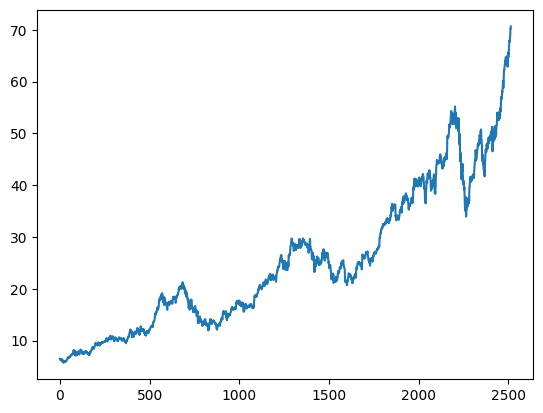

In [12]:
plt.plot(df.Close)

In [13]:
df.shape

(2515, 5)

In [14]:
# moving average for 100 days
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,57.275745
2511,57.473593
2512,57.710822
2513,57.938973


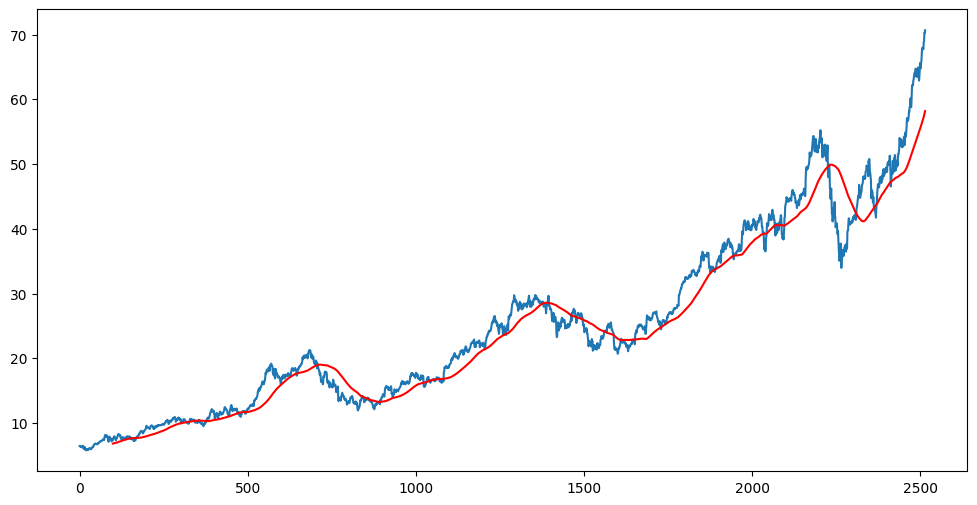

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')


In [16]:
# moving average for 200 days
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,52.221820
2511,52.349396
2512,52.482848
2513,52.613744


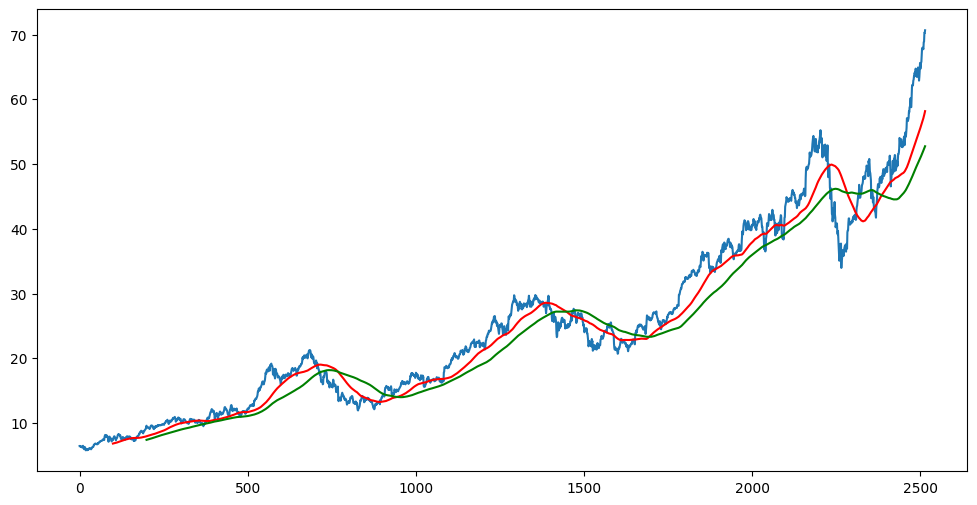

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200,'g')

In [18]:
# Splitting the data into training and test dataset

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

data_training.shape, data_testing.shape

((1760, 1), (755, 1))

In [19]:
data_training.head()
data_training.tail()

Ticker,AAPL
1755,27.102652
1756,26.924377
1757,26.977621
1758,27.148956
1759,27.033192


In [20]:
# now scaling down the data for model
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [21]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02759998],
       [0.02806516],
       [0.02377925],
       ...,
       [0.8840838 ],
       [0.8912316 ],
       [0.88640211]], shape=(1760, 1))

In [22]:
data_training_array[1759]

array([0.88640211])

In [23]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])    

In [24]:
x_train, y_train = np.array(x_train), np.array(y_train)

x_train.shape, y_train.shape

((1660, 100, 1), (1660,))

ML Model


In [44]:
pip install keras

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------------------------ --------------- 0.8/1.3 MB 1.5 MB/s eta 0:00:01
   -------------------------------- ------- 1.0/1.3 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 1.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
   ------- -------------------------------- 0.5/3.0 MB 1.4 MB/s eta 0:00:02
   ---------- ----------------------------- 0.8/3.0 MB 1.5 MB/s eta 0:00:02
   -------------- ------------------------- 1.0/3.0 MB 1.5 MB/s eta 0:00:02
   --------------------- ------------------ 1.6/3.0 MB 1.6 MB/s eta 0:00:01
   ------------------------ --------------- 1.8/3.0 MB 1.6 MB/s eta 0:00:01
   ------------------------------- -------- 2.4

In [2]:
pip install tensorflow

  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/390.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/390.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/390.3 MB ? eta -:--:--
   ---------------------------------------- 0.5/390.3 MB 985.5 kB/s eta 0:06:36
   ---------------------------------------- 0.8/390.3 MB 1.1 MB/s eta 0:06:01
   ---------------------------------------- 1.0/390.3 MB 1.2 MB/s eta 0:05:26
   ---------------------------------------- 1.3/390.3 MB 1.2 MB/s eta 0:05:31
   ---------------------------------------- 1.6/390.3 MB 1.2 MB/s eta 0:05:25
   ---------------------------------------- 1.8/390.3 MB 1.2 MB/s eta 0:05:21
   ---------------------------------------- 2.1/390.3 MB 1.2 MB/s eta 0:05:18
   ---------------------------------------- 2.4/390.3 MB 1.2 MB/s eta 0:05:13
   ---------------------------------------- 2.6/390.3 MB 1.2 MB/s eta 0:05:11
   -----------------

  You can safely remove it manually.
  You can safely remove it manually.


In [4]:
pip install --upgrade numpy

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 2.4 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/12.6 MB 2.6 MB/s eta 0:00:05
   ---- ----------------------------------- 1.6/12.6 MB 2.6 MB/s eta 0:00:05
   ----- ---------------------------------- 1.8/12.6 MB 2.5 MB/s eta 0:00:05
   ------- -------------------------------- 2.4/12.6 MB 2.4 MB/s eta 0:00:05
   --------- ------------------------------ 2.9/12.6 MB 2.5 MB/s eta 0:00:04
   ---------- ----------------------------- 3.4/12.6 MB 2.5 MB/s eta 0:00:04
   ----------- ---------------------------- 3.7/12.6 MB 2.4 MB/s eta 0:00:04
   ------------ --------------------------- 3.9/12.6 MB 2.3 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.6 MB 2.1 MB/s eta 0:00:05
   -------------- ------------------------- 4.7/12.6 MB 2.1 MB/s eta 0:00:04
   --------------- ------------------------ 5.0/12.6 MB 2.0 MB/s eta 0:00:04
   ---

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.2 which is incompatible.


In [5]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [26]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, 
               input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences = True ))
model.add(Dropout(0.3))


model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))


c:\Users\Aniket\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.1199
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0125
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0103
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0091
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0084
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0074
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0097
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0098
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0068
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - loss: 0.0070
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0073
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0070
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0061
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0063
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - l

In [29]:
model.save('keras_model.h5')

In [30]:
data_testing.head()


Ticker,AAPL
1760,27.026245
1761,26.815561
1762,26.891962
1763,26.861864
1764,26.998459


In [31]:
past_100_days = data_training.tail(100)


In [33]:
import pandas as pd

# Assuming past_100_days and data_testing are DataFrames
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [34]:
final_df.head()

Ticker,AAPL
0,24.962509
1,25.063862
2,24.877287
3,24.861160
4,24.918745


In [36]:
input_data = scaler.fit_transform(final_df)
input_data.shape

(855, 1)

In [41]:
x_test=[]
y_test=[]

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [43]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)

(755, 100, 1)


Making Predictions


In [44]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


In [46]:
y_predicted

array([[0.11815165],
       [0.11924344],
       [0.12040183],
       [0.12157422],
       [0.12268606],
       [0.12367766],
       [0.12450849],
       [0.12517539],
       [0.12569459],
       [0.12609838],
       [0.12642103],
       [0.12668198],
       [0.1269004 ],
       [0.12711844],
       [0.12734991],
       [0.12761387],
       [0.12795521],
       [0.12839489],
       [0.12893048],
       [0.12957121],
       [0.13033395],
       [0.13121398],
       [0.13219102],
       [0.1332481 ],
       [0.13444775],
       [0.1358669 ],
       [0.13757375],
       [0.13962507],
       [0.14206396],
       [0.1448964 ],
       [0.14809847],
       [0.15159208],
       [0.1552204 ],
       [0.1589026 ],
       [0.16256633],
       [0.16621953],
       [0.16986863],
       [0.17347173],
       [0.17700936],
       [0.18047342],
       [0.18382874],
       [0.18703629],
       [0.19007222],
       [0.19292226],
       [0.19557683],
       [0.19803122],
       [0.20028506],
       [0.202

In [47]:
# now again we have to scale up the values by the factor it is scaled down


In [48]:
scaler.scale_

array([0.02132179])

In [49]:
scale_factor = 1/0.02132179
y_predicted = y_predicted*scale_factor
y_test = y_test*scale_factor


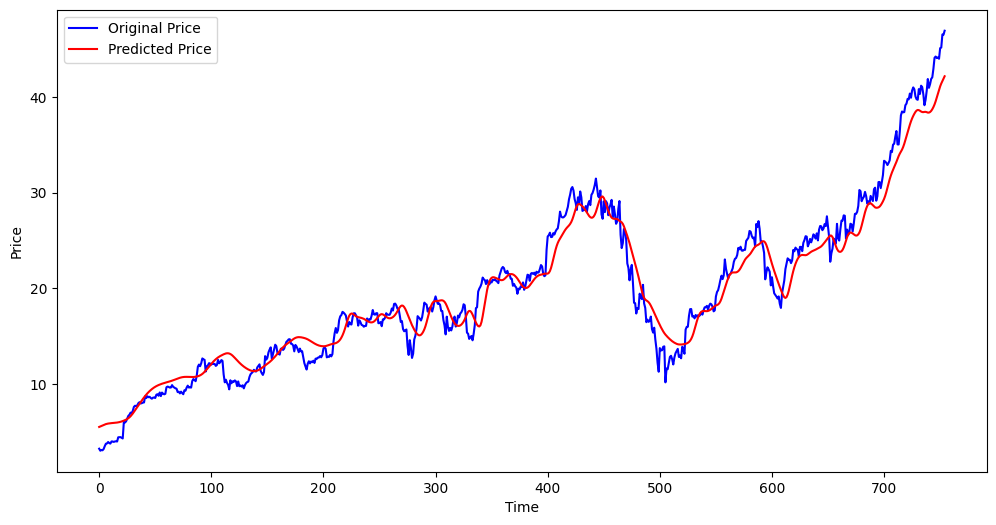

In [50]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_predicted, 'r', label = 'Predicted Price')   
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()